In [1]:
"""
01_eda_adult.ipynb

Exploratory Data Analysis for the UCI Adult dataset.
Understand variable distributions, missing values, and select the target
subgroup for synthetic demographic shift generation.

Author: Marco Pérez Padilla
Date:   10-08-2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_DIR = Path("../data")

In [2]:
# Load raw data
COLUMN_NAMES = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]

df = pd.read_csv(
    DATA_DIR / "adult.data",
    header=None,
    names=COLUMN_NAMES,
    skipinitialspace=True,
    na_values="?",
)

print(f"Shape: {df.shape}")
df.head(10)

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
# Nulls inspection
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print(f"\n% nulls over total: {(nulls.sum() / len(df)) * 100:.2f}%")

workclass         1836
occupation        1843
native_country     583
dtype: int64

% nulls over total: 13.09%


In [10]:
# Numeric variables and their statistics
num_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
df[num_cols].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


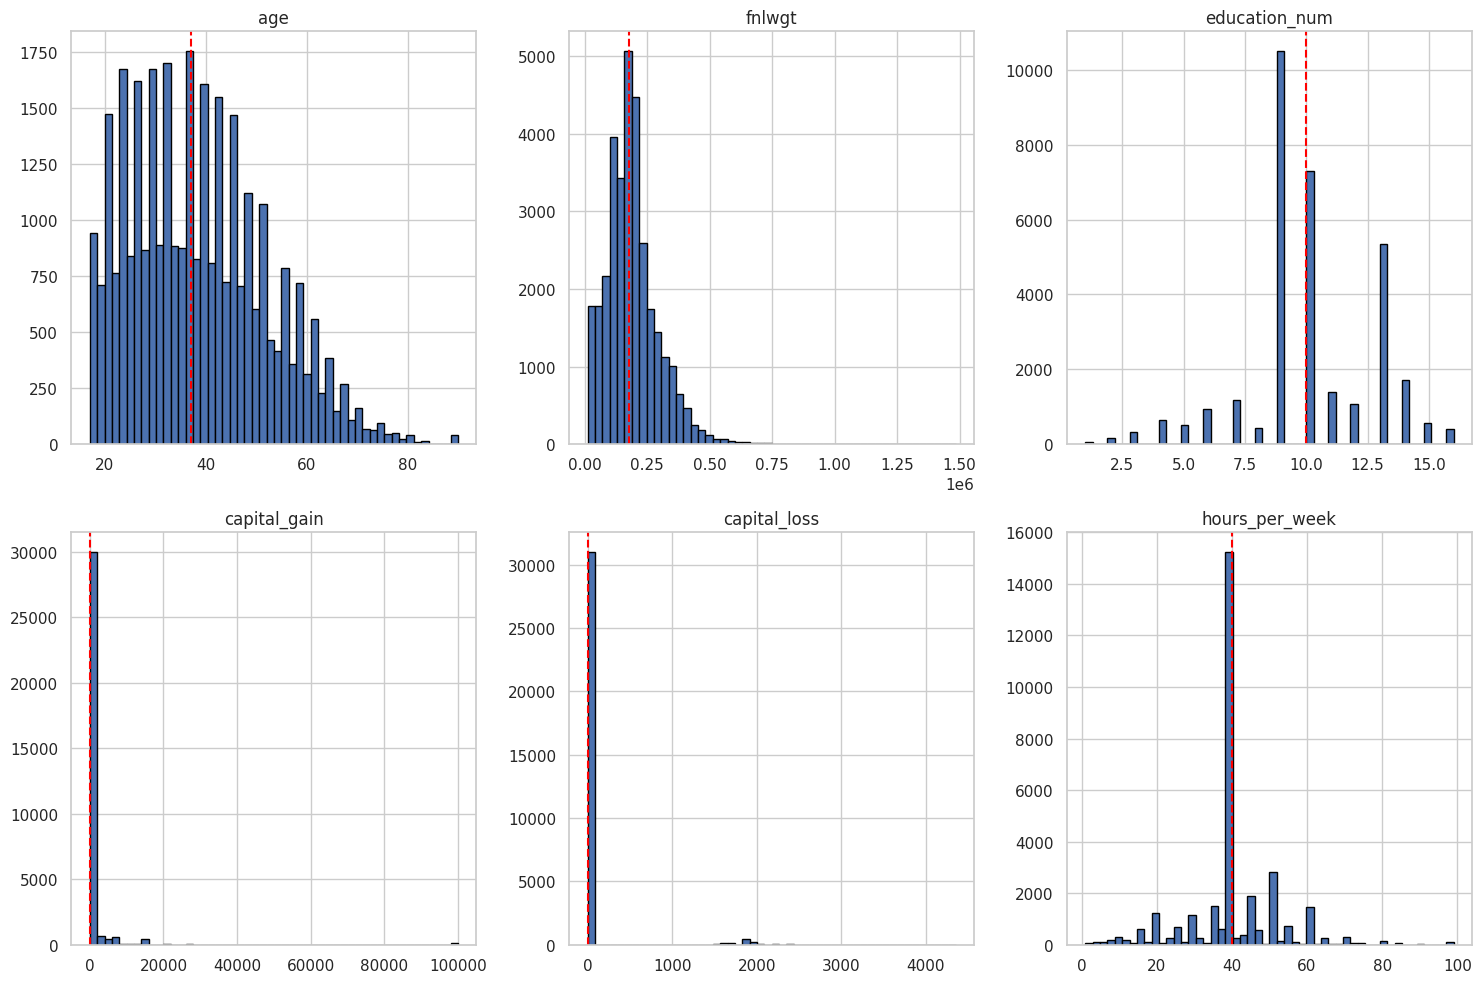

In [11]:
# Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, num_cols):
    df[col].hist(bins=50, ax=ax, edgecolor="black")
    ax.set_title(col)
    ax.axvline(df[col].median(), color="red", linestyle="--", label="median")
plt.tight_layout()
plt.show()

In [13]:
# Categoric variables
cat_cols = ["workclass", "education", "marital_status", "occupation",
            "relationship", "race", "sex", "native_country", "income"]

for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"  {col}")
    print(f"{'='*50}")
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({"count": counts, "%": pcts.round(2)})
    print(summary.head(10))


  workclass
                  count      %
workclass                     
Private           22696  73.87
Self-emp-not-inc   2541   8.27
Local-gov          2093   6.81
State-gov          1298   4.22
Self-emp-inc       1116   3.63
Federal-gov         960   3.12
Without-pay          14   0.05
Never-worked          7   0.02

  education
              count      %
education                 
HS-grad       10501  32.25
Some-college   7291  22.39
Bachelors      5355  16.45
Masters        1723   5.29
Assoc-voc      1382   4.24
11th           1175   3.61
Assoc-acdm     1067   3.28
10th            933   2.87
7th-8th         646   1.98
Prof-school     576   1.77

  marital_status
                       count      %
marital_status                     
Married-civ-spouse     14976  45.99
Never-married          10683  32.81
Divorced                4443  13.65
Separated               1025   3.15
Widowed                  993   3.05
Married-spouse-absent    418   1.28
Married-AF-spouse         23   0.0

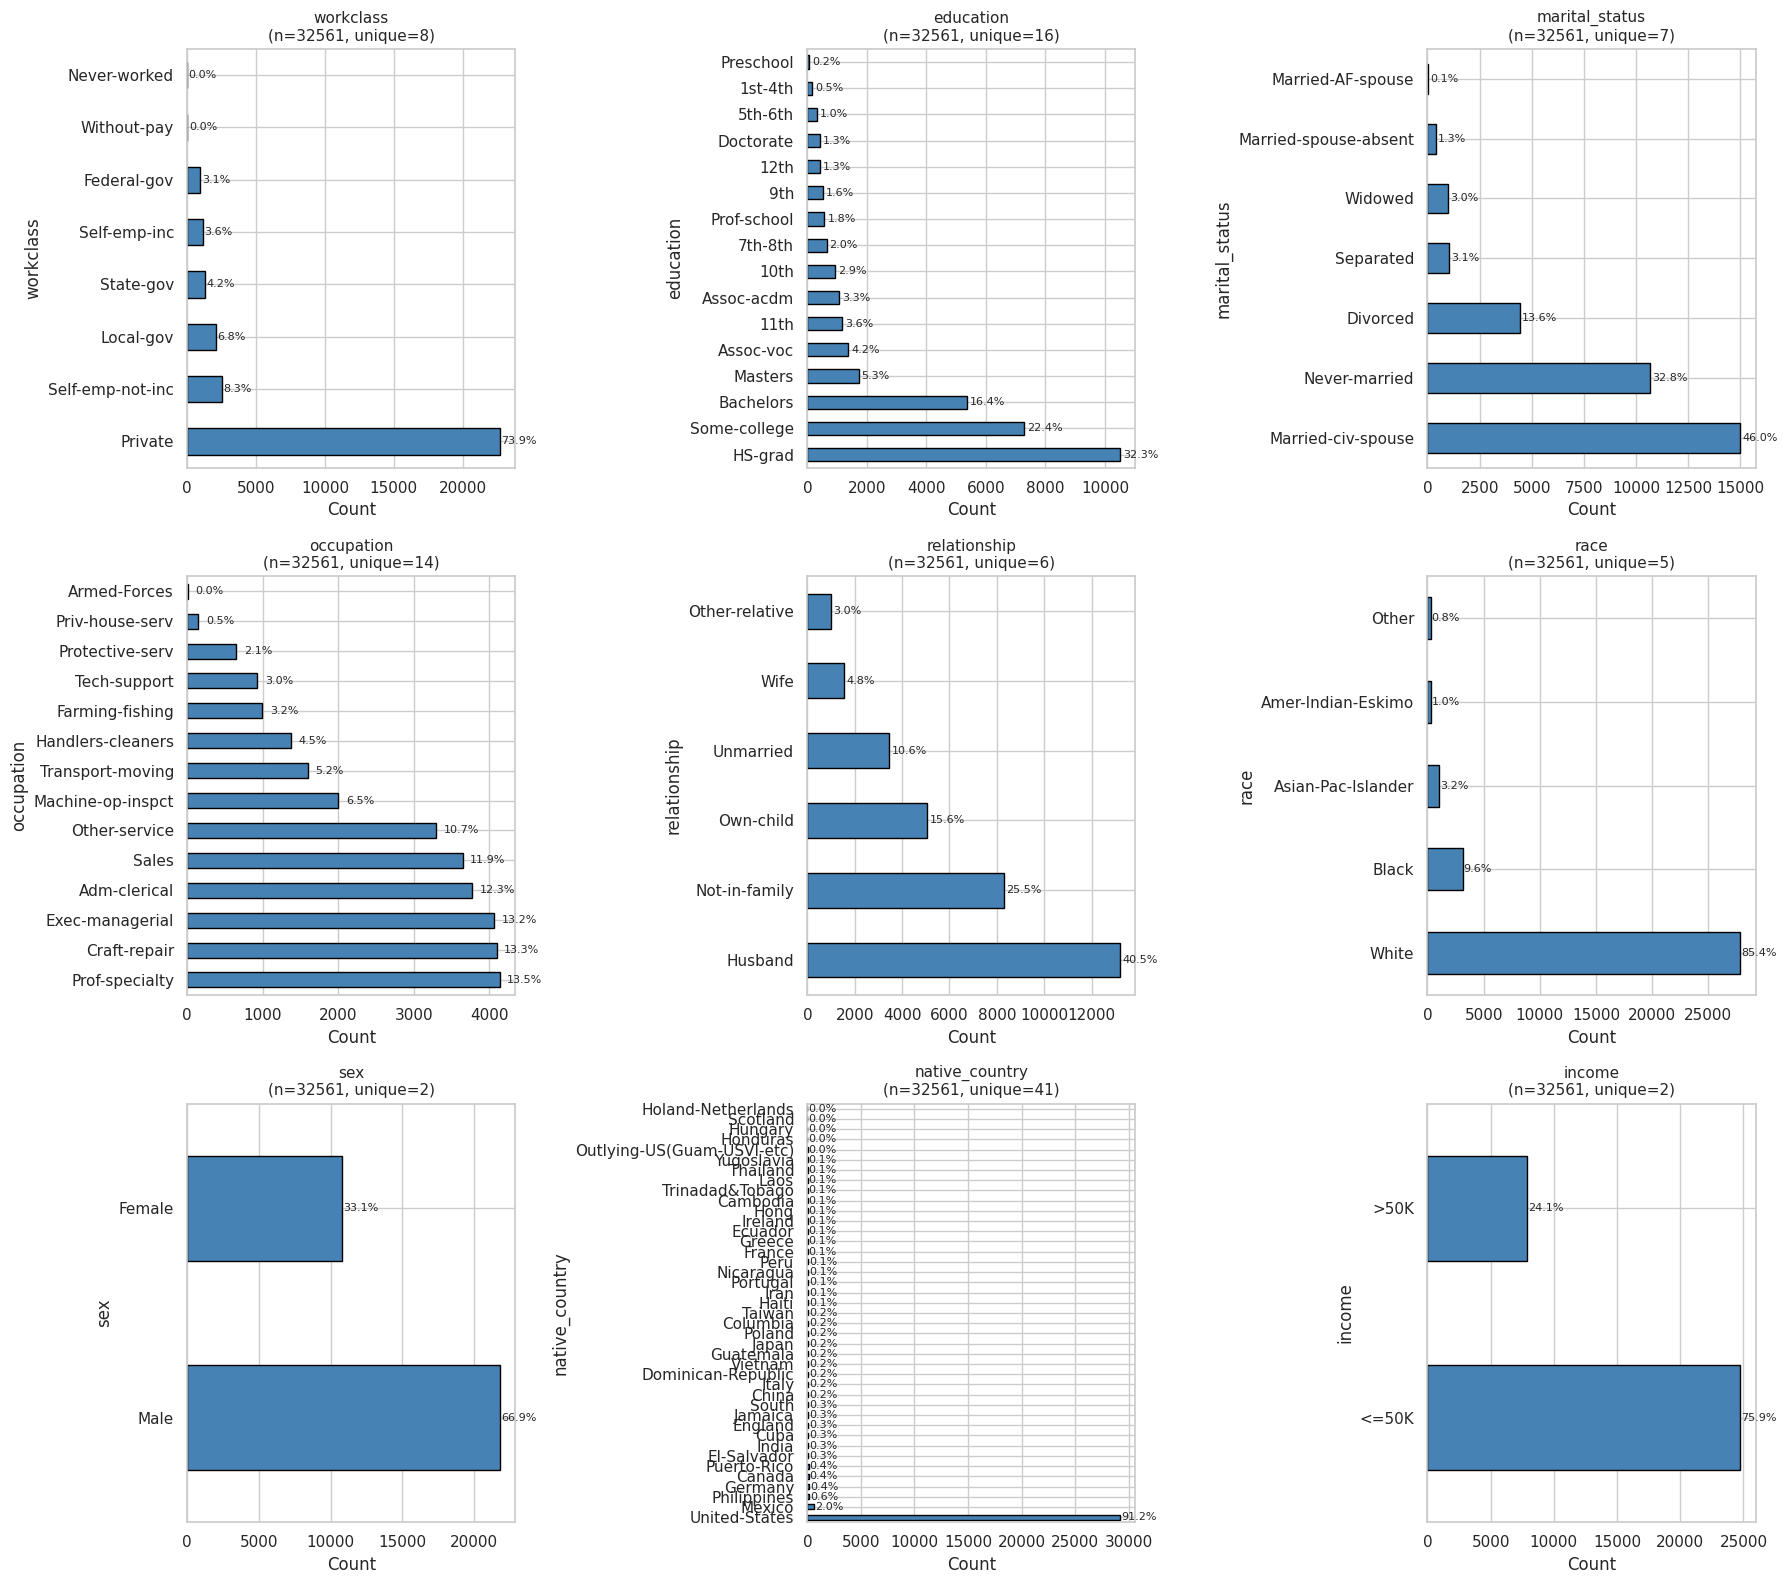

In [16]:
# Categorical variables — visual distributions
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{col}\n(n={len(df)}, unique={df[col].nunique()})", fontsize=11)
    ax.set_xlabel("Count")
    
    total = counts.sum()
    for i, v in enumerate(counts.values):
        ax.text(v + 100, i, f"{v/total*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# We'll be choosing income as target, given it's the standard binary label for this dataset.
# However, ShiftBench does NOT predict income. We only detect drift on the features.
# Income is kept in the DataFrame for completeness but excluded from drift detection.

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


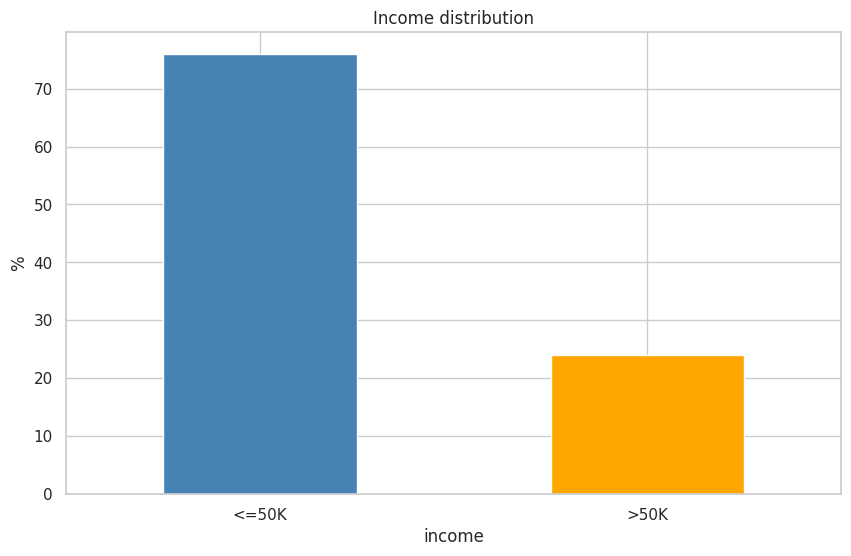

In [18]:
# Target variable: income
income_pct = df["income"].value_counts(normalize=True) * 100
print(income_pct)
income_pct.plot(kind="bar", color=["steelblue", "orange"])
plt.title("Income distribution")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

In [19]:
# Studying best variable for ShiftBench

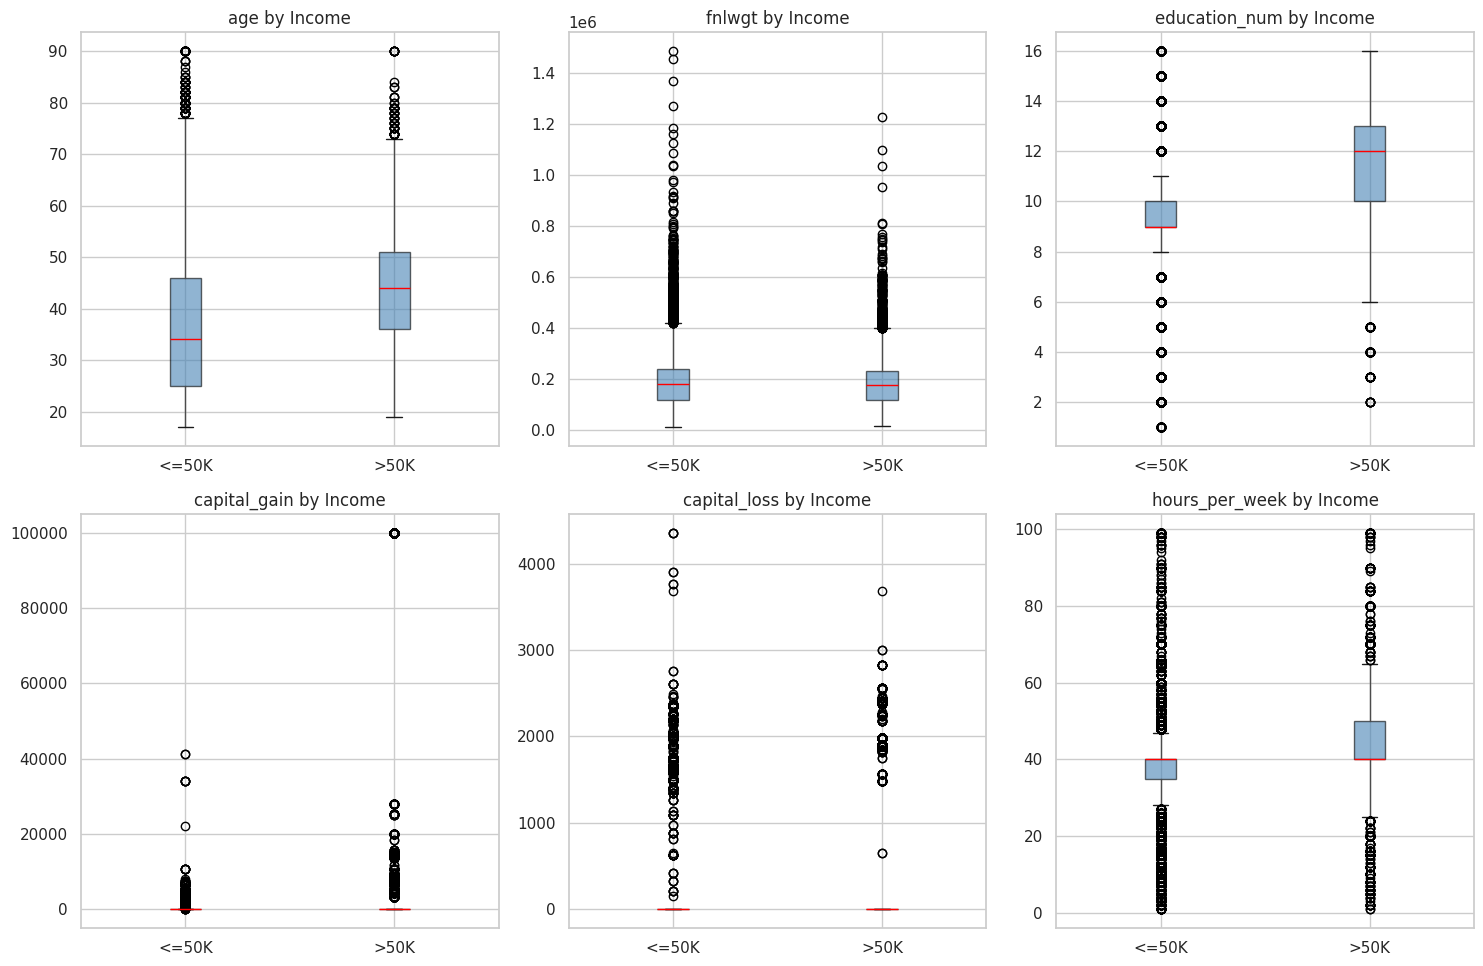

In [20]:
# Numeric variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="income", ax=ax, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="red"))
    ax.set_title(f"{col} by Income")
    ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

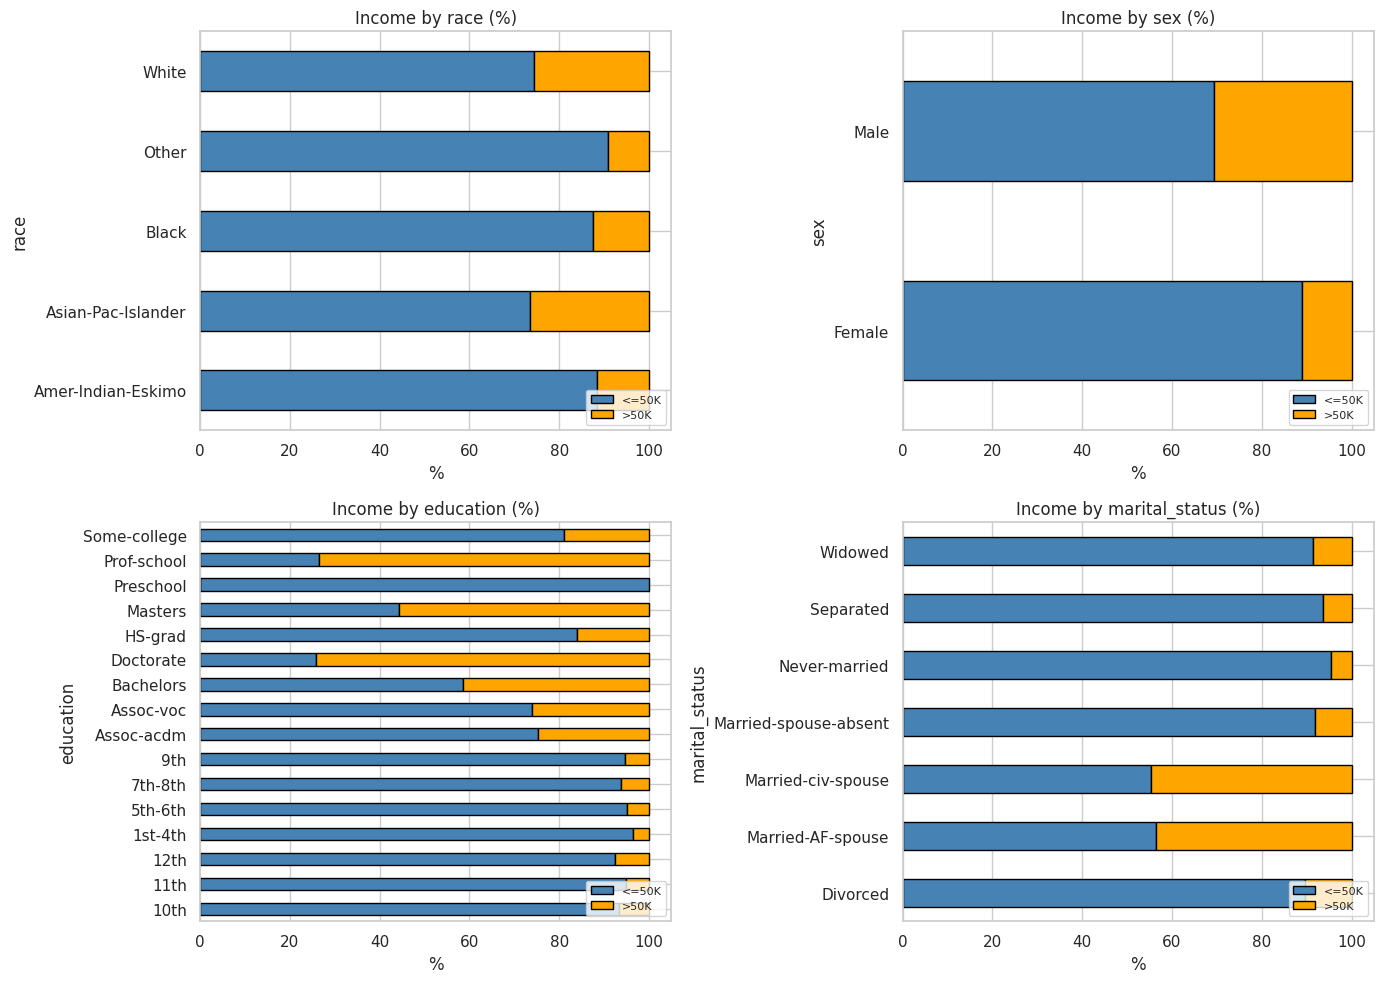

In [21]:
# Categoric variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

candidates = ["race", "sex", "education", "marital_status"]

for ax, col in zip(axes, candidates):
    ct = pd.crosstab(df[col], df["income"], normalize="index") * 100
    ct.plot(kind="barh", stacked=True, ax=ax, color=["steelblue", "orange"], edgecolor="black")
    ax.set_title(f"Income by {col} (%)")
    ax.set_xlabel("%")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
# First candidate: Race (BLack). Second: Sex (Female)

Income distribution by race (%):
income              <=50K  >50K
race                           
Amer-Indian-Eskimo   88.4  11.6
Asian-Pac-Islander   73.4  26.6
Black                87.6  12.4
Other                90.8   9.2
White                74.4  25.6


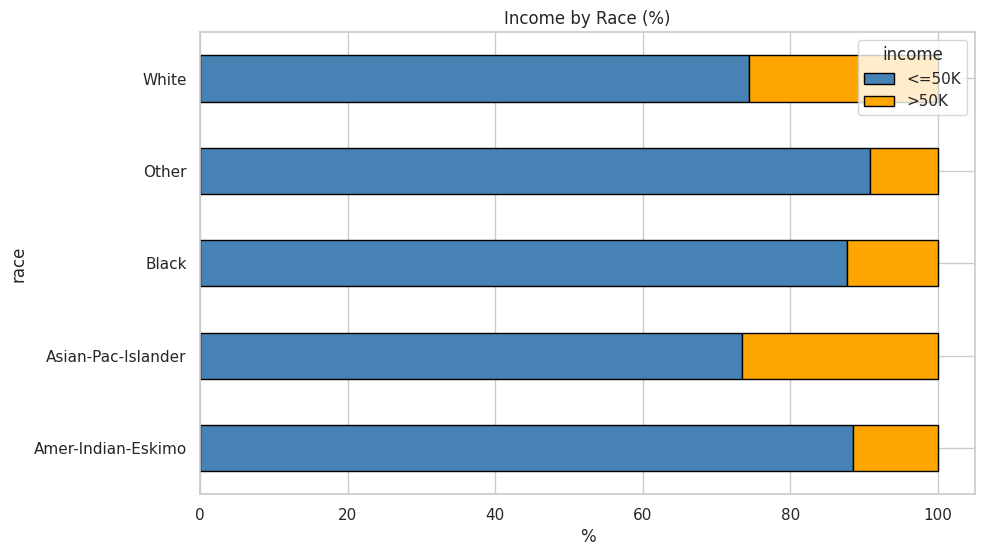

In [24]:
# Race (Detailed)
race_income = pd.crosstab(df["race"], df["income"], normalize="index") * 100
print("Income distribution by race (%):")
print(race_income.round(1))

race_income.plot(kind="barh", stacked=True, color=["steelblue", "orange"], edgecolor="black")
plt.title("Income by Race (%)")
plt.xlabel("%")
plt.show()

Income distribution by sex (%):
income  <=50K  >50K
sex                
Female   89.1  10.9
Male     69.4  30.6


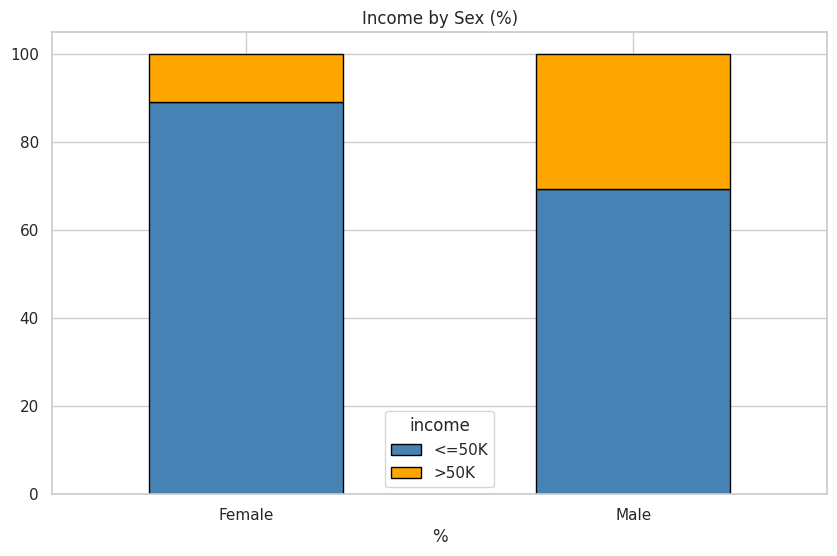

In [25]:
# Sex (Detailed)
sex_income = pd.crosstab(df["sex"], df["income"], normalize="index") * 100
print("Income distribution by sex (%):")
print(sex_income.round(1))

sex_income.plot(kind="bar", stacked=True, color=["steelblue", "orange"], edgecolor="black")
plt.title("Income by Sex (%)")
plt.xlabel("%")
plt.xticks(rotation=0)
plt.show()

In [28]:
race_black_pct = (df["race"] == "Black").mean() * 100
sex_female_pct = (df["sex"] == "Female").mean() * 100

print(" SHIFT CANDIDATE SELECTION")
print(f" race = Black:  {race_black_pct:.1f}% of data")
print(f" sex = Female:  {sex_female_pct:.1f}% of data")
print()
print(" Chosen: race = Black")
print("    - Smaller baseline proportion (9.6% vs 33.1%)")
print("    - Wider α range for gradual synthetic shift")
print("    - Demographically meaningful and realistic")
print("    - Different income distribution vs majority groups")


 SHIFT CANDIDATE SELECTION
 race = Black:  9.6% of data
 sex = Female:  33.1% of data

 Chosen: race = Black
    - Smaller baseline proportion (9.6% vs 33.1%)
    - Wider α range for gradual synthetic shift
    - Demographically meaningful and realistic
    - Different income distribution vs majority groups


In [29]:
print("""
EDA CONCLUSIONS FOR SHIFTBENCH:

1. Dataset: 32,561 rows × 15 columns after cleaning (dropna).

2. Missing values to handle:
   - workclass: 5.6% null
   - occupation: 5.7% null
   - native_country: 1.8% null
   → Strategy: drop rows with any null (lose ~7.4% of data).

3. Selected shift: demographic shift on race = "Black".
   - α = 0.0 → 9.6% Black (original distribution)
   - α = 1.0 → 100% Black (maximum shift)

4. Features to use for drift detection (all except income):
   - 6 numerical: age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week
   - 8 categorical: workclass, education, marital_status, occupation, relationship,
     race, sex, native_country
""")


EDA CONCLUSIONS FOR SHIFTBENCH:

1. Dataset: 32,561 rows × 15 columns after cleaning (dropna).

2. Missing values to handle:
   - workclass: 5.6% null
   - occupation: 5.7% null
   - native_country: 1.8% null
   → Strategy: drop rows with any null (lose ~7.4% of data).

3. Selected shift: demographic shift on race = "Black".
   - α = 0.0 → 9.6% Black (original distribution)
   - α = 1.0 → 100% Black (maximum shift)

4. Features to use for drift detection (all except income):
   - 6 numerical: age, fnlwgt, education_num, capital_gain, capital_loss, hours_per_week
   - 8 categorical: workclass, education, marital_status, occupation, relationship,
     race, sex, native_country

